This notebook contains experiments that connect generalization performance with geometric and information-theoretic clustering. The data is created synthetically, but should represent a two-dimensional latent space and an encoder with Gaussian noise.

Class centroids are drawn from a circular Gaussian distribution. Data representations are drawn from a circular Gaussian distribution centered in the class mean, and superimposed by circular Gaussian noise. We compute compression and generalization as a function of the variances of these three distributions.

In [1]:
import numpy as np
# import entropy_estimators
from sklearn.metrics.pairwise import euclidean_distances

N=1000
K=10
runs=50
N_K=np.floor(N/K)

In [3]:
var_rep_list=[1, 0.1, 0.01, 0.001, 0.0001]
var_noise_list=[1, 0.1, 0.01, 0.001, 0.0001] #[1, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0005,0.0002,0.0001]

IXZY_analytical=np.zeros((len(var_rep_list),len(var_noise_list)))
NC=np.zeros((len(var_rep_list),len(var_noise_list),runs))

for ind_rep in range(len(var_rep_list)):
    var_rep=var_rep_list[ind_rep]
    for ind_noise in range(len(var_noise_list)):
        var_noise=var_noise_list[ind_noise]
        IXZY_analytical[ind_rep,ind_noise] = np.log2(1+var_rep/var_noise)
        for run in range(runs):
            class_means=np.random.multivariate_normal([0,0],np.eye(2),K)
            X=[]
            y=[]
            for ind in range(K):
                representations=np.random.multivariate_normal(class_means[ind,:],np.eye(2)*var_rep,size=int(N_K))
                X.append(representations)
                y.append(ind*np.ones(int(N_K)))

            X=np.array(X)
            X=X.reshape(int(N_K)*K,2)

            Z=X+np.random.multivariate_normal([0,0],np.eye(2)*var_noise,size=int(N_K)*K)

            y=np.array(y)
            y=y.reshape(int(N_K)*K)

            mat=1./(euclidean_distances(class_means,squared=True) + 1e-8)
            np.fill_diagonal(mat,0)
            NC[ind_rep,ind_noise,run] = (var_rep+var_noise)*sum(sum(mat))/(K*(K-1))

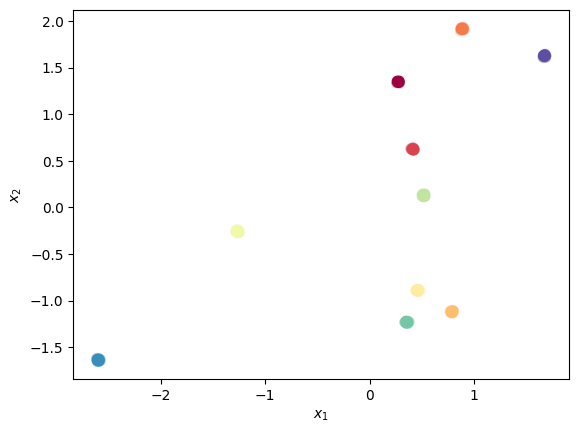

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0],X[:,1],c=y,alpha=0.2,cmap='Spectral')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

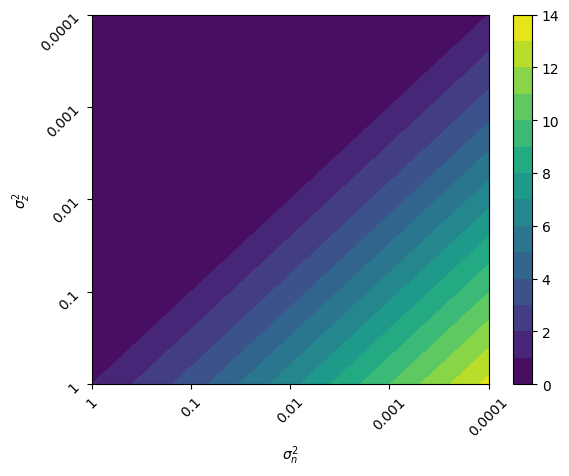

In [7]:
plt.contourf(IXZY_analytical,levels=15)
plt.colorbar()
plt.yticks(range(len(var_rep_list)),var_rep_list,rotation=45)
plt.ylabel(r'$\sigma_z^2$')
plt.xticks(range(len(var_noise_list)),var_noise_list,rotation=45)
plt.xlabel(r'$\sigma_n^2$')
plt.show()

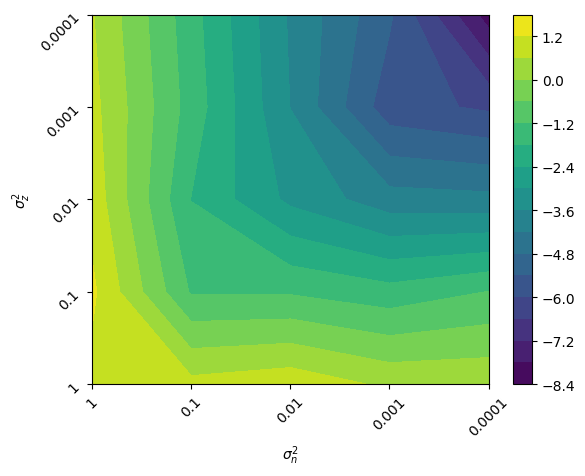

In [8]:
NC_mean=np.mean(NC,axis=2)
plt.contourf(np.log(NC_mean),levels=15)
plt.yticks(range(len(var_rep_list)),var_rep_list,rotation=45)
plt.ylabel(r'$\sigma_z^2$')
plt.xticks(range(len(var_noise_list)),var_noise_list,rotation=45)
plt.xlabel(r'$\sigma_n^2$')
plt.colorbar()
plt.show()